# Panel

This section showcases the panel. It contains examples of how to overlay several charts in one coordinate space using the [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-panel), which maps common tasks to the parameter or per-figure option that does the job.

A panel does not draw data of its own: it takes figures already drawn by the chart functions of the [datachart.charts](../../../references/charts/) module — any of the charts from the [Charts](../../charts/) guides — and redraws them into one coordinate space, with a shared x-axis and up to two y-axes. Where the [Grid](../grid/) keeps every figure in a coordinate space of its own, the panel reads them against each other on shared axes: reach for a grid to compare charts side by side, and for a panel to overlay them. The `Panel` function is found in the [datachart.utils](../../../references/utils/) module. Let's import it, together with the two chart functions the examples below overlay:

In [1]:
from datachart.charts import BarChart, LineChart
from datachart.utils import Panel

## Panel Input Attributes

The `Panel` function accepts a list of figures as its first argument and keyword arguments for the panel configuration. Each item of the list is either a bare figure returned by a chart function, or a dictionary with the figure and its per-figure options.

```python
Panel(
    [                                                   # A list of figures to overlay, each one either
        Figure,                                         #   a bare datachart figure, or
        {                                               #   a dict with the figure and its per-figure options
            "figure": Figure,                           # The datachart figure (required)
            "y_axis": Optional[str],                    # Which y-axis the figure is drawn on ("auto", "left", "right")
            "z_order": Optional[int],                   # The drawing order (higher values are drawn on top)
            "legend_label": Optional[str],              # The legend label (overrides the chart subtitle)
            "emphasis": Optional[str],                  # The emphasis role of the figure ("background", "highlight")
        },
    ],
    title=Optional[str],                                # The title of the panel
    xlabel=Optional[str],                               # The x-axis label
    ylabel_left=Optional[str],                          # The left y-axis label
    ylabel_right=Optional[str],                         # The right y-axis label
    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    show_legend=Optional[bool],                         # Whether to show the legend (default: False)
    show_grid=Optional[str],                            # Which grid lines to show ("both", "x", "y")
    auto_secondary_axis=Optional[float],                # The scale ratio above which a figure moves to the right y-axis
    xmin=Optional[Union[int, float]],                   # The x-axis range
    xmax=Optional[Union[int, float]],
    ymin=Optional[Union[int, float]],                   # The left y-axis range
    ymax=Optional[Union[int, float]],
    ymin_right=Optional[Union[int, float]],             # The right y-axis range
    ymax_right=Optional[Union[int, float]],
    bar_mode=Optional[BAR_MODE],                        # How overlaid bar charts share the axis ("group", "stack", "overlay")
)
```

For more details, see the [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) function. The reference is generated from the function itself, so it always lists the current parameters and per-figure options.

## Basics

The examples in this guide share one dataset: the monthly climate normals of Ljubljana's weather station — the mean temperature (in °C) and the total precipitation (in mm) of each month, rounded from the published values. Plotted together they form a *climograph*, the standard chart of a climate: precipitation as bars, temperature as a line, each on its own y-axis. The data lives in a hidden cell.

In [2]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C
TEMPERATURE = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# total monthly precipitation in mm
PRECIPITATION = [69, 70, 88, 99, 109, 144, 115, 137, 147, 147, 130, 107]

precipitation_data = [
    {"label": month, "y": value} for month, value in zip(MONTHS, PRECIPITATION)
]
temperature_data = [{"x": i, "y": value} for i, value in enumerate(TEMPERATURE)]

A panel overlays figures, so the first step is to draw each chart on its own. The precipitation is a bar chart with one labeled bar per month; the temperature is a line chart whose `x` values are the month indices, so its points land on the bars. The `subtitle` of each chart becomes its label in the panel legend:

In [3]:
precipitation = BarChart(data=precipitation_data, subtitle="Precipitation (mm)")
temperature = LineChart(data=temperature_data, subtitle="Temperature (°C)")

**Basic example.** Only the list of figures is required to draw the panel. The figures are drawn in the order given, the months of the bar chart label the shared x-axis, and the y-axes are assigned automatically: the temperature spans about 20 units while the precipitation spans about 80, so the temperature moves to a second y-axis on the right. The [Axis assignment](#axis-assignment) section explains the rule and how to override it.

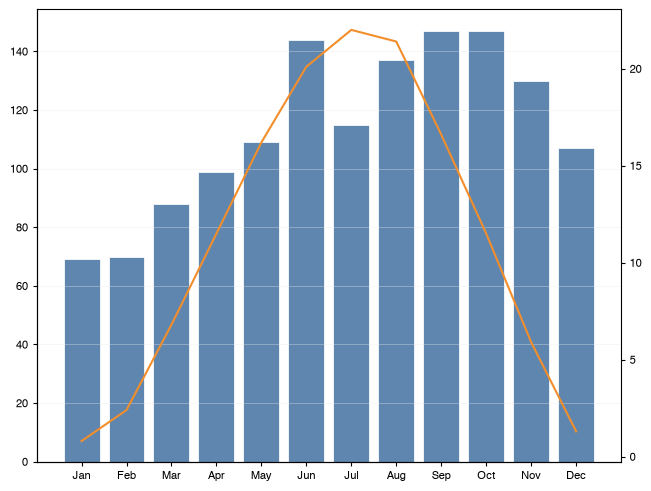

In [4]:
Panel(
    # add the figures to the panel
    [precipitation, temperature]
).show()

## Customizing the Panel

Every customization is either a keyword argument of `Panel` or a per-figure option of the dictionary wrapping a figure. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel_left`, `ylabel_right`                        | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| show which figure is which                  | `show_legend`, the charts' `subtitle`, per-figure `"legend_label"`      | [Legend](#legend) |
| put a figure on the right y-axis            | per-figure `"y_axis"`                                                   | [Axis assignment](#axis-assignment) |
| tune the automatic axis assignment          | `auto_secondary_axis`                                                   | [Axis assignment](#axis-assignment) |
| bring a figure to the front                 | per-figure `"z_order"`                                                  | [Drawing order](#drawing-order) |
| highlight one figure, mute the rest         | per-figure `"emphasis"`                                                 | [Emphasis](#emphasis) |
| limit the axes                              | `xmin`, `xmax`, `ymin`, `ymax`, `ymin_right`, `ymax_right`              | [Axis limits](#axis-limits) |
| overlay several bar charts                  | `bar_mode`                                                              | [Bar mode](#bar-mode) |
| add a figure to an existing panel           | nest `Panel` figures                                                    | [Nesting panels](#nesting-panels) |
| overlay horizontal bars                     | `orientation` on the bar charts, the same `Panel` parameters           | [Horizontal panels](#horizontal-panels) |
| change the defaults of every panel          | `config.update_config` with the `overlay_*` settings                    | [Panel configuration](#panel-configuration) |
| save the panel to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of parameters and per-figure options is in the [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) function. The look of each figure — colors, line widths, markers — is set on the chart itself through its `style` attribute; see the guide of each chart in the [Charts](../../charts/) section.

### Title and axis labels

To add the panel title and axis labels, add the `title`, `xlabel`, `ylabel_left` and `ylabel_right` attributes. The panel has one x-axis and up to two y-axes, so the y-axis label is given per side; `ylabel_right` is only drawn when a figure is assigned to the right y-axis.

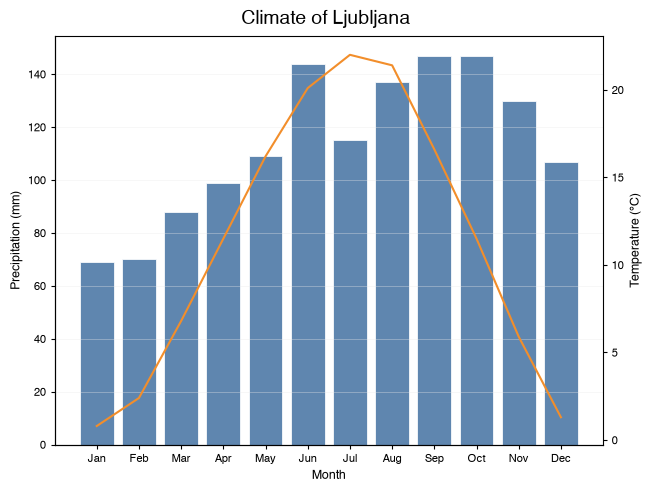

In [5]:
Panel(
    [precipitation, temperature],
    # add the title
    title="Climate of Ljubljana",
    # add the x and y axis labels
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains the most common figure sizes.

To add the grid, add the `show_grid` attribute. The possible options are:

| Option | Description |
| --- | --- |
| `"both"` | shows both the x-axis and the y-axis gridlines. |
| `"x"` | shows only the x-axis grid lines. |
| `"y"` | shows only the y-axis grid lines. |

Again, `datachart` provides a [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant, which contains the supported options. The grid follows the left y-axis.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

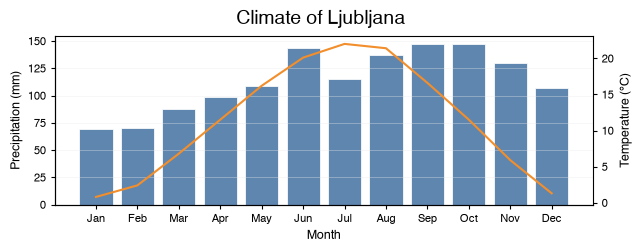

In [7]:
Panel(
    [precipitation, temperature],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines
    show_grid=SHOW_GRID.Y,
).show()

### Legend

To show the legend, add the `show_legend` attribute set to `True`. The legend merges the entries of every figure and labels each one with the `subtitle` of its chart; when the panel has two y-axes, an `(L)` or `(R)` suffix tells which axis an entry is read against. To label a figure differently in the panel than on its own, wrap it in a dictionary and add the `"legend_label"` option, which overrides the subtitle:

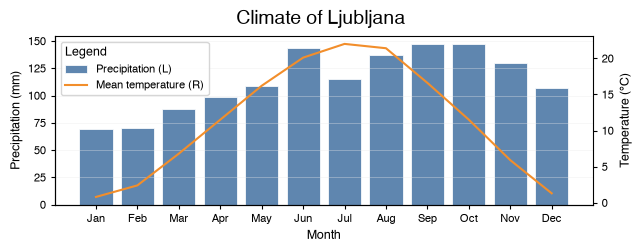

In [8]:
Panel(
    [
        # override the subtitle of the chart in the legend
        {"figure": precipitation, "legend_label": "Precipitation"},
        {"figure": temperature, "legend_label": "Mean temperature"},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # add to show the legend
    show_legend=True,
).show()

### Axis assignment

To choose the y-axis a figure is drawn on, wrap it in a dictionary and add the `"y_axis"` option, which supports the following values:

| Value | Description |
| :---- | :---------- |
| `"auto"` | The panel picks the axis from the scale of the data (the default). |
| `"left"` | The figure is drawn on the left y-axis. |
| `"right"` | The figure is drawn on the right y-axis. |

In `"auto"` mode the panel compares the span of the values of each figure: figures whose spans differ by more than the `auto_secondary_axis` ratio (default `3.0`) are put on different y-axes, the larger group on the left. The temperature spans about 20 units and the precipitation about 80, a ratio of about 4, which is why the [basic example](#basics) already has two y-axes. An explicit `"y_axis"` is the robust choice whenever you know which axis a figure belongs to — the data can change, the assignment should not:

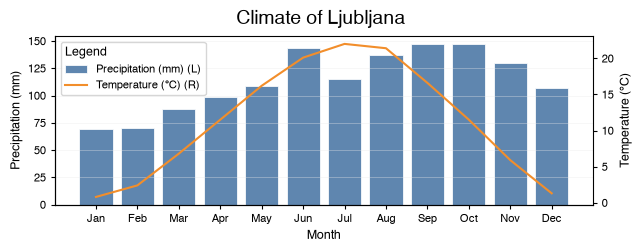

In [9]:
Panel(
    [
        # assign each figure to its y-axis explicitly
        {"figure": precipitation, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

To keep the automatic assignment but make it more or less eager, add the `auto_secondary_axis` attribute with the ratio of your choice. A ratio above the 4 of this dataset keeps both figures on the left y-axis, where the temperature is squeezed against the bottom — the reason the panel splits the axes in the first place:

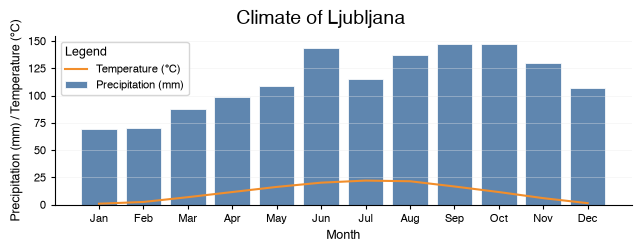

In [10]:
Panel(
    [precipitation, temperature],
    # only split the axes when the spans differ more than tenfold
    auto_secondary_axis=10.0,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm) / Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Drawing order

The figures are drawn in the order given, later ones on top of earlier ones. To change the order, wrap a figure in a dictionary and add the `"z_order"` option: figures with a higher value are drawn on top of figures with a lower value, whatever their position in the list. When no `"z_order"` is given, each chart type takes the default of its kind from the [panel configuration](#panel-configuration) — bars and histograms sit behind lines and scatter points, so a line is never hidden by the bars it is read against. The example reverses that: the bars are drawn over the line.

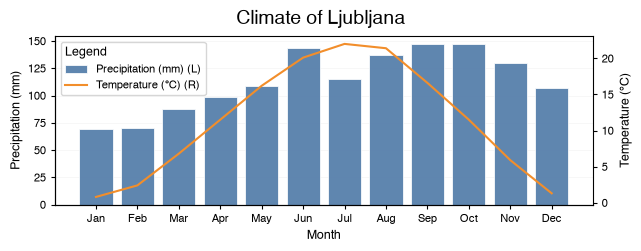

In [11]:
Panel(
    [
        # draw the bars on top of the line
        {"figure": precipitation, "y_axis": "left", "z_order": 2},
        {"figure": temperature, "y_axis": "right", "z_order": 1},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Emphasis

To draw attention to one figure, wrap the figures in dictionaries and add the `"emphasis"` option, which applies one role to every layer of the figure:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the figure: it takes the muted color of the active theme, is pushed behind the other figures, and is dropped from the legend. |
| `"highlight"` | Bolds the figure and brings it to the front of the data layers. |
| `None` | Leaves the figure unchanged. |

Again, `datachart` provides a [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant, which contains the supported options; the [Highlighting](../../styling/highlighting/) guide covers the emphasis vocabulary across the package. Here the precipitation is context and the temperature the message:

In [12]:
from datachart.constants import EMPHASIS

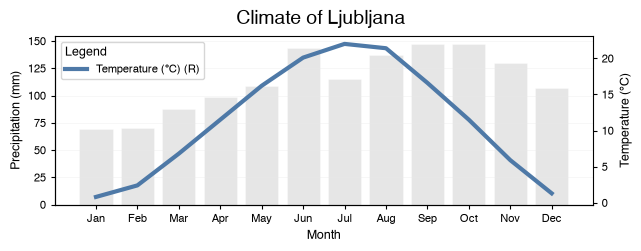

In [13]:
Panel(
    [
        # mute the bars, bold the line
        {"figure": precipitation, "y_axis": "left", "emphasis": EMPHASIS.BACKGROUND},
        {"figure": temperature, "y_axis": "right", "emphasis": EMPHASIS.HIGHLIGHT},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Axis limits

To set the range of an axis, add the `xmin`, `xmax`, `ymin` and `ymax` attributes; `ymin` and `ymax` apply to the left y-axis, `ymin_right` and `ymax_right` to the right one. Limits set on the individual charts are not carried over, the panel owns its axes. With labeled bars the x positions are the indices of the labels, so half-integer limits cut between two months. The example zooms in on April to September and starts both y-axes at zero, which puts the two quantities on an honest footing and leaves room for the legend:

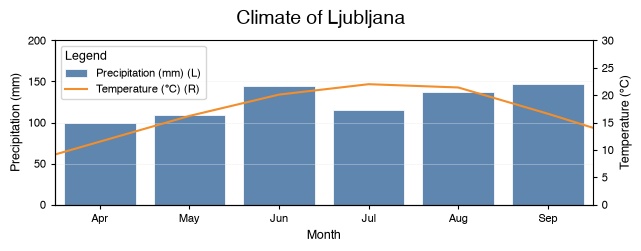

In [14]:
Panel(
    [
        {"figure": precipitation, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    # zoom in on April to September
    xmin=2.5,
    xmax=8.5,
    # start both y-axes at zero
    ymin=0,
    ymax=200,
    ymin_right=0,
    ymax_right=30,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Bar mode

When several bar charts are overlaid, the `bar_mode` attribute decides how their bars share each category, with the following values:

| Value | Description |
| :---- | :---------- |
| `"group"` | The bars of each category are drawn side by side (the default). |
| `"stack"` | The bars of each category are stacked on top of each other. |
| `"overlay"` | The bars of each category are drawn over each other, with transparency. |

Again, `datachart` provides a [datachart.constants.BAR_MODE](../../../references/constants/#datachart.constants.BAR_MODE) constant, which contains the supported options. The example splits the precipitation into the rain and the snow of each month — the split is illustrative — and stacks them, so the bars add up to the monthly total while the temperature line stays on its own axis:

In [15]:
from datachart.constants import BAR_MODE

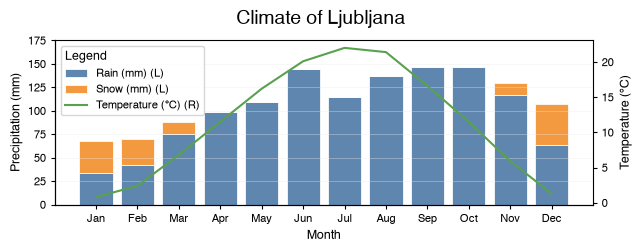

In [16]:
# an illustrative split of the monthly precipitation into snow (cold months) and rain
SNOW_SHARE = [0.5, 0.4, 0.15, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.4]
snow = BarChart(
    data=[
        {"label": month, "y": round(total * share)}
        for month, total, share in zip(MONTHS, PRECIPITATION, SNOW_SHARE)
    ],
    subtitle="Snow (mm)",
)
rain = BarChart(
    data=[
        {"label": month, "y": round(total * (1 - share))}
        for month, total, share in zip(MONTHS, PRECIPITATION, SNOW_SHARE)
    ],
    subtitle="Rain (mm)",
)

Panel(
    [
        {"figure": rain, "y_axis": "left"},
        {"figure": snow, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    # stack the bars of the two bar charts
    bar_mode=BAR_MODE.STACK,
    # headroom above the tallest stack
    ymin=0,
    ymax=175,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Nesting panels

Panel figures nest: `Panel([Panel([f1, f2]), f3])` is equivalent to `Panel([f1, f2, f3])`, to any depth. A nested panel contributes its figures with their per-figure options intact, while the panel-level settings — title, labels, limits — always come from the outermost call. This makes it easy to add a figure to a panel you have already built, such as the stacked precipitation above extended with the temperature:

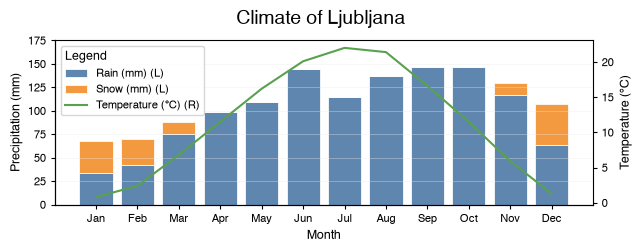

In [17]:
# an existing panel...
precipitation_panel = Panel(
    [
        {"figure": rain, "y_axis": "left"},
        {"figure": snow, "y_axis": "left"},
    ],
    bar_mode=BAR_MODE.STACK,
)

# ...later extended with an additional figure
Panel(
    [precipitation_panel, {"figure": temperature, "y_axis": "right"}],
    bar_mode=BAR_MODE.STACK,
    ymin=0,
    ymax=175,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Horizontal panels

A panel takes its orientation from the figures it holds: it is horizontal when every bar chart (and histogram) in it is horizontal, vertical otherwise, and mixing the two raises a `ValueError`. Line and scatter figures have no orientation of their own and follow the panel — in a horizontal panel their `x` runs along the categories and their `y` along the values, so the same temperature line overlays vertical and horizontal bars.

The parameters keep their names but address the axes by role. The *value axis* carries the quantities (x in a horizontal panel) and the *category axis* the labels (y): `ylabel_left`, `ylabel_right`, `ymin`, `ymax`, `ymin_right` and `ymax_right` refer to the value axes, `xlabel`, `xmin` and `xmax` to the category axis. The secondary value axis sits at the top, so `"y_axis": "right"` places a figure on the top axis and the legend marks the two with `(B)` and `(T)`. Only `show_grid` keeps its literal meaning — it names the gridlines you see.


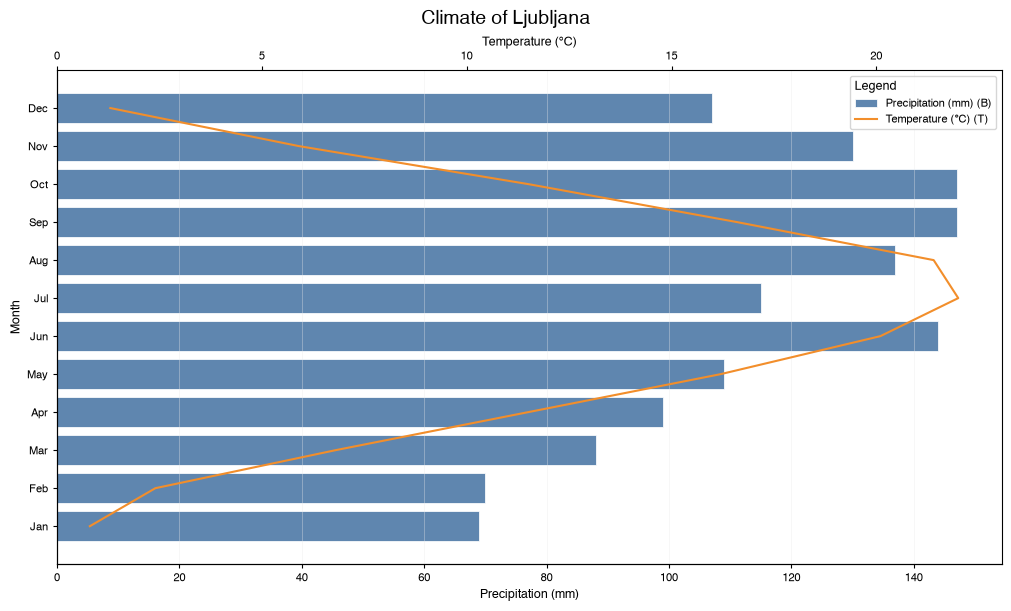

In [18]:
from datachart.constants import ORIENTATION

# horizontal bars make the panel horizontal
precipitation_h = BarChart(
    data=precipitation_data,
    subtitle="Precipitation (mm)",
    orientation=ORIENTATION.HORIZONTAL,
)

Panel(
    [
        {"figure": precipitation_h, "y_axis": "left"},
        # "right" is the top value axis in a horizontal panel
        {"figure": temperature, "y_axis": "right"},
    ],
    title="Climate of Ljubljana",
    # the category axis (y) and the two value axes (bottom and top)
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    # start both value axes at zero
    ymin=0,
    ymin_right=0,
    figsize=(10, 6),
    # gridlines keep their literal spelling: vertical lines along the values
    show_grid=SHOW_GRID.X,
    show_legend=True,
).show()


## Panel Configuration

The defaults the panel falls back on — the automatic axis threshold, the transparency of overlaid bars and histograms, the default drawing order of each chart type, the bar mode — are part of the global configuration, under the keys that start with `overlay_`. They are changed like any other setting, through [datachart.config.config.update_config](../../../references/config/#datachart.config.Config.update_config); see the [Config](../../styling/config/) guide for the configuration system as a whole. The current keys and their values in the active theme are:

In [19]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("overlay_")}

{'overlay_auto_threshold': 3.0,
 'overlay_bar_alpha': 0.7,
 'overlay_hist_alpha': 0.6,
 'overlay_default_zorder_bar': 1,
 'overlay_default_zorder_line': 2,
 'overlay_default_zorder_scatter': 2,
 'overlay_default_zorder_hist': 1,
 'overlay_bar_mode': 'group',
 'overlay_warn_thin_bars': True,
 'overlay_warn_scale_groups': True}

A setting given to `Panel` directly, such as `auto_secondary_axis` or `bar_mode`, always wins over the configuration. The configuration is the place for a default that should hold for every panel of a document:

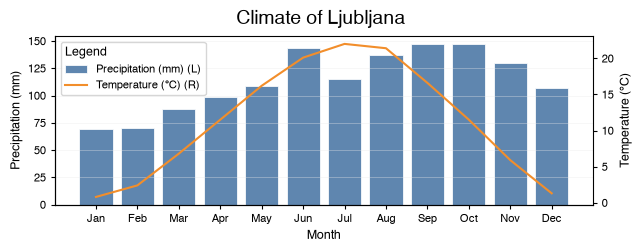

In [20]:
config.update_config(
    {
        # split the y-axes sooner
        "overlay_auto_threshold": 2.0,
        # draw overlaid bars more transparent
        "overlay_bar_alpha": 0.5,
    }
)

Panel(
    [precipitation, temperature],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

# restore the defaults for the rest of the guide
config.reset_config()

## Saving the Chart as an Image

To save the panel as an image, use the [datachart.utils.save_figure](../../../references/utils/#datachart.utils.save_figure) function.

In [21]:
from datachart.utils import save_figure

In [22]:
figure = Panel(
    [
        {"figure": precipitation, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
)
save_figure(figure, "./fig_panel.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell. The chart functions they overlay are imported as needed; any chart from the [Charts](../../charts/) guides can take part in a panel.

### Example 1: Enzyme Kinetics (Observed Points and a Fitted Model)

`observed` holds the illustrative reaction velocity of an enzyme at 15 substrate concentrations, drawn from the Michaelis–Menten equation with seeded measurement noise, and `model` the noise-free curve at 100 concentrations. Overlaying the measurements as a scatter chart and the model as a line chart is the standard way to show how well a model explains the data; the two share the same units, so they share one y-axis and the default `"auto"` assignment leaves it at that.

In [23]:
import numpy as np

rng = np.random.RandomState(42)
# Michaelis-Menten parameters: maximum velocity and the Michaelis constant
V_MAX, K_M = 50, 20
substrate = np.linspace(0, 100, 15)
observed = [
    {"x": float(s), "y": float(V_MAX * s / (K_M + s) + rng.randn() * 2)}
    for s in substrate
]
curve = np.linspace(0, 100, 100)
model = [{"x": float(s), "y": float(V_MAX * s / (K_M + s))} for s in curve]

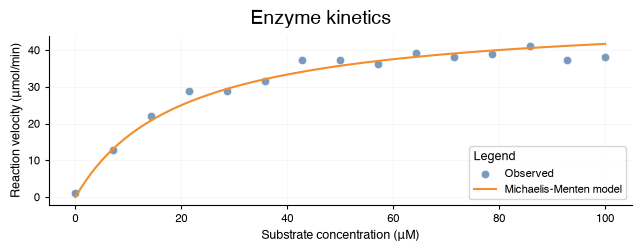

In [24]:
from datachart.charts import ScatterChart

Panel(
    [
        ScatterChart(data=observed, subtitle="Observed"),
        LineChart(data=model, subtitle="Michaelis-Menten model"),
    ],
    title="Enzyme kinetics",
    xlabel="Substrate concentration (μM)",
    ylabel_left="Reaction velocity (μmol/min)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.BOTH,
    show_legend=True,
).show()

### Example 2: Cell Size Distribution (Histogram and a Fitted Curve)

`diameters` holds the illustrative diameter (in μm) of 250 cells measured under a microscope, drawn from a seeded normal generator, and `normal_fit` the normal density with the same mean and standard deviation, scaled to the bin width and the sample size so it is comparable with the histogram counts. The curve is drawn on top of the histogram by default — histograms take the background drawing order — and reads against it on the same y-axis.

In [25]:
rng = np.random.RandomState(42)
MEAN, STD, N_CELLS, N_BINS = 12.5, 2.3, 250, 25
measurements = rng.normal(MEAN, STD, N_CELLS)
diameters = [{"x": float(x)} for x in measurements]
# the normal density scaled to the histogram counts: N * bin width * pdf(x)
bin_width = (measurements.max() - measurements.min()) / N_BINS
grid = np.linspace(measurements.min(), measurements.max(), 150)
density = N_CELLS * bin_width * np.exp(-0.5 * ((grid - MEAN) / STD) ** 2) / (STD * np.sqrt(2 * np.pi))
normal_fit = [{"x": float(x), "y": float(y)} for x, y in zip(grid, density)]

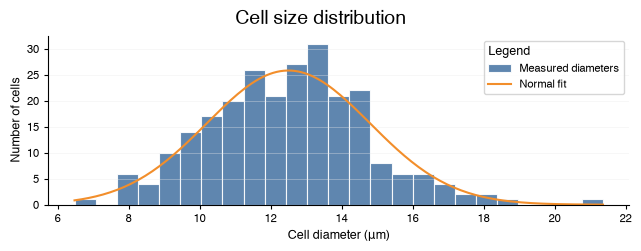

In [26]:
from datachart.charts import Histogram

Panel(
    [
        Histogram(data=diameters, num_bins=N_BINS, subtitle="Measured diameters"),
        LineChart(data=normal_fit, subtitle="Normal fit"),
    ],
    title="Cell size distribution",
    xlabel="Cell diameter (μm)",
    ylabel_left="Number of cells",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Example 3: Cell Viability Under Treatment (Grouped Bars and a Trend Line)

`viability_24h` and `viability_48h` hold the illustrative viability (in % of the untreated control) of cells after 24 and 48 hours under four treatments, and `viability_mean` the mean of the two. Two bar charts in a panel are grouped side by side by the default `bar_mode`, and the `"z_order"` of the line lifts the mean above both so it is never hidden behind a bar. The chart `style` keeps the two time points in two greys so the red trend line carries the message.

In [27]:
CONDITIONS = ["Control", "Drug A", "Drug B", "Drug C", "Combination"]
VIABILITY_24H = [100, 85, 78, 82, 65]
VIABILITY_48H = [100, 72, 68, 75, 48]
viability_24h = [{"label": c, "y": v} for c, v in zip(CONDITIONS, VIABILITY_24H)]
viability_48h = [{"label": c, "y": v} for c, v in zip(CONDITIONS, VIABILITY_48H)]
viability_mean = [
    {"x": i, "y": (a + b) / 2} for i, (a, b) in enumerate(zip(VIABILITY_24H, VIABILITY_48H))
]

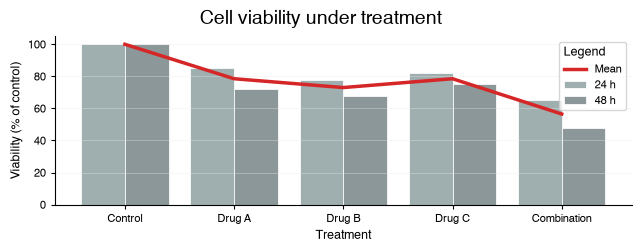

In [28]:
Panel(
    [
        BarChart(data=viability_24h, subtitle="24 h", style={"plot_bar_color": "#95a5a6"}),
        BarChart(data=viability_48h, subtitle="48 h", style={"plot_bar_color": "#7f8c8d"}),
        {
            "figure": LineChart(
                data=viability_mean,
                subtitle="Mean",
                style={"plot_line_color": "#d62728", "plot_line_width": 2.5},
            ),
            # draw the trend line over the bars
            "z_order": 3,
        },
    ],
    title="Cell viability under treatment",
    xlabel="Treatment",
    ylabel_left="Viability (% of control)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Example 4: Seismic Monitoring (Emphasis on the Events)

`baseline` holds 200 minutes of illustrative ground acceleration (in g) of a seismometer at rest, drawn from a seeded generator, and `tremor` and `earthquake` two events — a minor tremor and a larger earthquake — as bell-shaped bursts over the same baseline. The baseline is context: the `"background"` emphasis mutes it and drops it from the legend, so the two events, each in its own chart and color, are what the reader sees. The events dwarf the baseline — a span ratio of about 12 — so the default axis assignment would move the baseline to its own y-axis and blow it up; raising `auto_secondary_axis` above that ratio keeps every figure on one scale, the whole point being that the events stand out against the baseline.

In [29]:
rng = np.random.RandomState(42)
REST = 0.02
baseline = [{"x": t, "y": float(REST + rng.randn() * 0.005)} for t in range(200)]


def event(center, width, peak, noise, span):
    # a bell-shaped burst of ground acceleration around `center`
    return [
        {"x": t, "y": float(REST + peak * np.exp(-0.5 * ((t - center) / width) ** 2) + rng.randn() * noise)}
        for t in range(*span)
    ]


tremor = event(center=45, width=3, peak=0.15, noise=0.01, span=(35, 55))
earthquake = event(center=140, width=4, peak=0.35, noise=0.015, span=(128, 152))

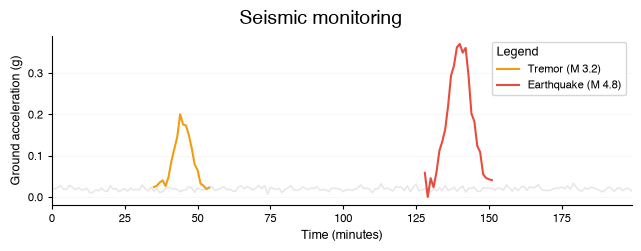

In [30]:
Panel(
    [
        # the baseline is context: mute it
        {"figure": LineChart(data=baseline, subtitle="Background"), "emphasis": EMPHASIS.BACKGROUND},
        LineChart(data=tremor, subtitle="Tremor (M 3.2)", style={"plot_line_color": "#f39c12"}),
        LineChart(data=earthquake, subtitle="Earthquake (M 4.8)", style={"plot_line_color": "#e74c3c"}),
    ],
    # one scale for everything, so the events stand out against the baseline
    auto_secondary_axis=20.0,
    title="Seismic monitoring",
    xlabel="Time (minutes)",
    ylabel_left="Ground acceleration (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()